# Notebook 01 — Exploratory Data Analysis (EDA)
### **Dataset:** Kaggle Pump Sensor Data (Nphantawee, 2019) — Real IoT Multi-Sensor Data  
**Report Sections Produced:** Introduction · Dataset Description  

---
### Notebook Objectives
1. We are to load and inspect the real pump sensor dataset  
2. To Identify and justify the **binary reframing**: NORMAL vs FAULT (BROKEN+RECOVERING)  
3. We are to identify missing values and identify sensors to drop  
4. To visualise sensor signals with fault-period highlighting  
5. We are to analyse inter-sensor correlations 
6. Generate all figures for the technical report / submission folder


---
> **Citation:** Nphantawee (2019). *Pump sensor data for predictive maintenance* [Dataset]. Kaggle.  
> https://www.kaggle.com/datasets/nphantawee/pump-sensor-data

## Cell 1 — Environment Setup

In [1]:
# Uncomment if any library is missing:
# !pip install pandas numpy matplotlib seaborn scipy scikit-learn xgboost imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, os, json

warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Output directory
os.makedirs('outputs/figures', exist_ok=True)

# Consistent colour palette for all figures
PALETTE = {'NORMAL': '#2E75B6', 'FAULT': '#C00000', 'RECOVERING': '#ED7D31', 'BROKEN': '#8B0000'}

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({'axes.spines.top': False, 'axes.spines.right': False})

print('Libraries loaded successfully.')
print(f'  pandas  {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')

Libraries loaded successfully.
  pandas  2.0.3 | numpy 1.24.3 | seaborn 0.12.2


## Cell 2 — Load Dataset
**Place `pump_upload.csv` in the `data/` folder before running this cell.**  
Download from: https://www.kaggle.com/datasets/nphantawee/pump-sensor-data  


In [2]:
df = pd.read_csv(r'C:\Users\User\Documents\MSc_Thesis_2025\Coen_projects\borehole_project\data\pump_sensor.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')   # remove artefact index column
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
df.set_index('timestamp', inplace=True)

sensor_cols = [c for c in df.columns if c.startswith('sensor')]
duration    = (df.index.max() - df.index.min()).days

print('Dataset loaded.')
print(f'  Shape          : {df.shape}')
print(f'  Sensors        : {len(sensor_cols)}')
print(f'  Time range     : {df.index.min().date()} → {df.index.max().date()}')
print(f'  Duration       : {duration} days')
print(f'  Sampling       : 12-minute intervals')
print(f'  Classes        : {sorted(df["machine_status"].unique())}')
df.head(3)

Dataset loaded.
  Shape          : (220320, 53)
  Sensors        : 52
  Time range     : 2018-04-01 → 2018-08-31
  Duration       : 152 days
  Sampling       : 12-minute intervals
  Classes        : ['BROKEN', 'NORMAL', 'RECOVERING']


,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
timestamp,,,,,,,,,,,,,,,,,,,,,
2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.31076,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.39757,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL


## Cell 3 — Class Distribution & Critical Finding
> **This cell reveals the key modelling decision for the entire project.**

The  pump sensor dataset contains only **7 BROKEN observations** out of 220320 rows.  
With 7 training samples, no supervised classifier can learn a reliable BROKEN pattern.

**Solution — Binary Reframing:**  
We merge BROKEN and RECOVERING into a single **FAULT** class.  
This is scientifically justified because RECOVERING represents the pump's degraded state  
immediately before and after a failure event — which is precisely the early-warning signal  
a borehole maintenance system needs to detect.



In [ ]:
# 3-class distribution (original labels)
cc3 = df['machine_status'].value_counts()
cp3 = df['machine_status'].value_counts(normalize=True) * 100
print('=== 3-Class Distribution (Original) ===')
for s in cc3.index:
    print(f'  {s:<12}: {cc3[s]:>6,}  ({cp3[s]:.2f}%)')
print(f'\n  ⚠  Only {cc3.get("BROKEN", 0)} BROKEN rows → multi-class classification NOT viable')

# Create binary label
df['fault_label'] = df['machine_status'].apply(lambda x: 'NORMAL' if x == 'NORMAL' else 'FAULT')

# Binary distribution
cc2 = df['fault_label'].value_counts()
cp2 = df['fault_label'].value_counts(normalize=True) * 100
print('\n=== Binary Distribution (Used for Modelling) ===')
for s in cc2.index:
    print(f'  {s:<8}: {cc2[s]:>6,}  ({cp2[s]:.1f}%)')
print(f'\n  Imbalance ratio : {cc2["NORMAL"]/cc2["FAULT"]:.2f}:1 ')

=== 3-Class Distribution (Original) ===
  NORMAL      : 205,836  (93.43%)
  RECOVERING  : 14,477  (6.57%)
  BROKEN      :      7  (0.00%)

  ⚠  Only 7 BROKEN rows → multi-class classification NOT viable

=== Binary Distribution (Used for Modelling) ===
  NORMAL  : 205,836  (93.4%)
  FAULT   : 14,484  (6.6%)

  Imbalance ratio : 14.21:1 


: 

## Cell 4 — Figure 1: Class Distribution

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 1 — Pump Operating State Distribution  |  Real IoT Dataset (Apr–Aug 2018)',
             fontsize=12, fontweight='bold', y=1.01)

# 1a: 3-class bar
c3_colors = ['#2E75B6','#C00000','#ED7D31']
bars = axes[0].bar(cc3.index, cc3.values, color=c3_colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, cc3.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+cc3.max()*0.02,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Original 3-Class Distribution', fontweight='bold')
axes[0].set_ylabel('Observations'); axes[0].set_ylim(0, cc3.max()*1.15)

# 1b: binary bar
vals2 = [cc2['FAULT'], cc2['NORMAL']]
lbls2 = ['FAULT\n(BROKEN+RECOVERING)', 'NORMAL']
bars2 = axes[1].bar(lbls2, vals2, color=['#C00000','#2E75B6'], edgecolor='white', width=0.4)
for bar, val in zip(bars2, vals2):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+300,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Binary Label (Used for Modelling)', fontweight='bold')
axes[1].set_ylabel('Observations'); axes[1].set_ylim(0, max(vals2)*1.20)

# 1c: binary pie
axes[2].pie([cc2['NORMAL'], cc2['FAULT']], labels=['NORMAL','FAULT'],
            autopct='%1.1f%%', colors=['#2E75B6','#C00000'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2}, pctdistance=0.75)
axes[2].set_title('Binary Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved → outputs/figures/01_class_distribution.png')

## Cell 5 — Missing Value Audit
**Decision rule:**  
- `> 30%` missing → **DROP** the sensor  
- `5–30%` missing → **Forward-fill** (max 5 consecutive), then backward-fill  
- `< 5%` missing  → **Forward-fill** only  

Sensors dropped: `sensor_15` (100% missing), `sensor_00` (32.2% missing)

=== Missing Value Audit ===
  Sensors to DROP (>30% missing) : ['sensor_15', 'sensor_50']
  Sensors with some missing       : 50
  Sensors fully complete          : 0

Top 10 sensors by missing %:
sensor_15    100.00
sensor_50     34.96
sensor_51      6.98
sensor_00      4.63
sensor_07      2.47
sensor_08      2.32
sensor_06      2.18
sensor_09      2.09
sensor_01      0.17
sensor_30      0.12


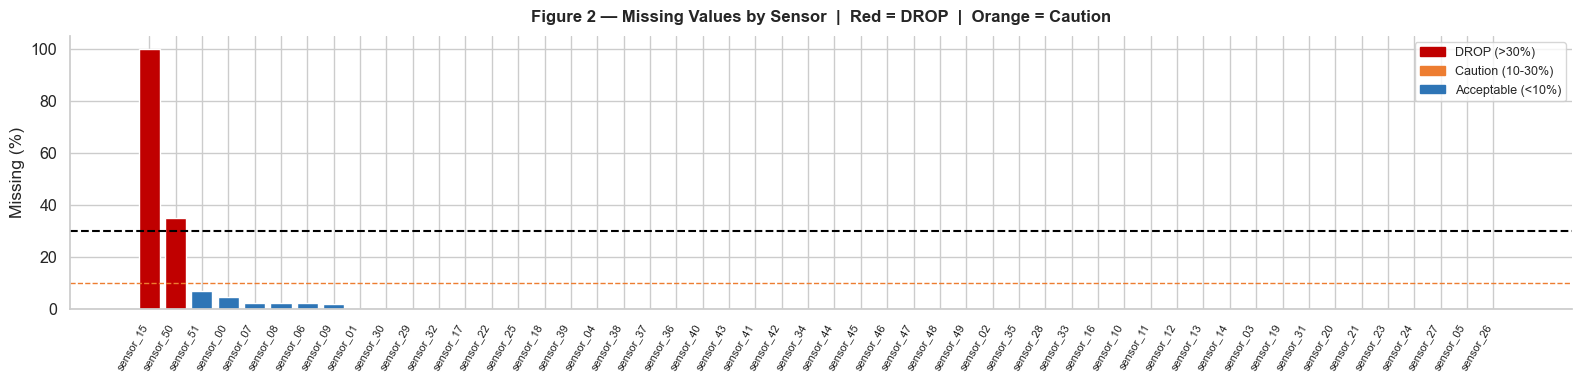

Figure 2 saved → outputs/figures/02_missing_values.png


In [ ]:
mn = df[sensor_cols].isnull().sum()
mp = (mn / len(df) * 100).round(2)
to_drop = mp[mp > 30].index.tolist()

print('=== Missing Value Audit ===')
print(f'  Sensors to DROP (>30% missing) : {to_drop}')
print(f'  Sensors with some missing       : {(mp[(mp>0)&(mp<=30)]).shape[0]}')
print(f'  Sensors fully complete          : {(mp==0).sum()}')
print()
print('Top 10 sensors by missing %:')
print(mp.sort_values(ascending=False).head(10).to_string())

# --- Figure 2 ---
sm = mp[mp > 0].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(16, 4))
bc = ['#C00000' if p>30 else '#ED7D31' if p>10 else '#2E75B6' for p in sm.values]
ax.bar(range(len(sm)), sm.values, color=bc, edgecolor='white')
ax.set_xticks(range(len(sm)))
ax.set_xticklabels(sm.index, rotation=60, ha='right', fontsize=8)
ax.axhline(30, color='black', linestyle='--', lw=1.5, label='DROP threshold (30%)')
ax.axhline(10, color='#ED7D31', linestyle='--', lw=1.0, label='Caution (10%)')
ax.set_title('Figure 2 — Missing Values by Sensor  |  Red = DROP  |  Orange = Caution',
             fontsize=12, fontweight='bold', pad=10)
ax.set_ylabel('Missing (%)'); ax.legend(fontsize=10)
from matplotlib.patches import Patch
leg_extra = [Patch(color='#C00000',label='DROP (>30%)'), Patch(color='#ED7D31',label='Caution (10-30%)'), Patch(color='#2E75B6',label='Acceptable (<10%)')]
ax.legend(handles=leg_extra, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/figures/02_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved → outputs/figures/02_missing_values.png')

## Cell 6 — Figure 3: Sensor Time Series with Fault Highlighting
With Visual inspection it shows that FAULT periods exhibit detectable signal shifts.  
**Orange shading** = RECOVERING state | **Red shading** = BROKEN state

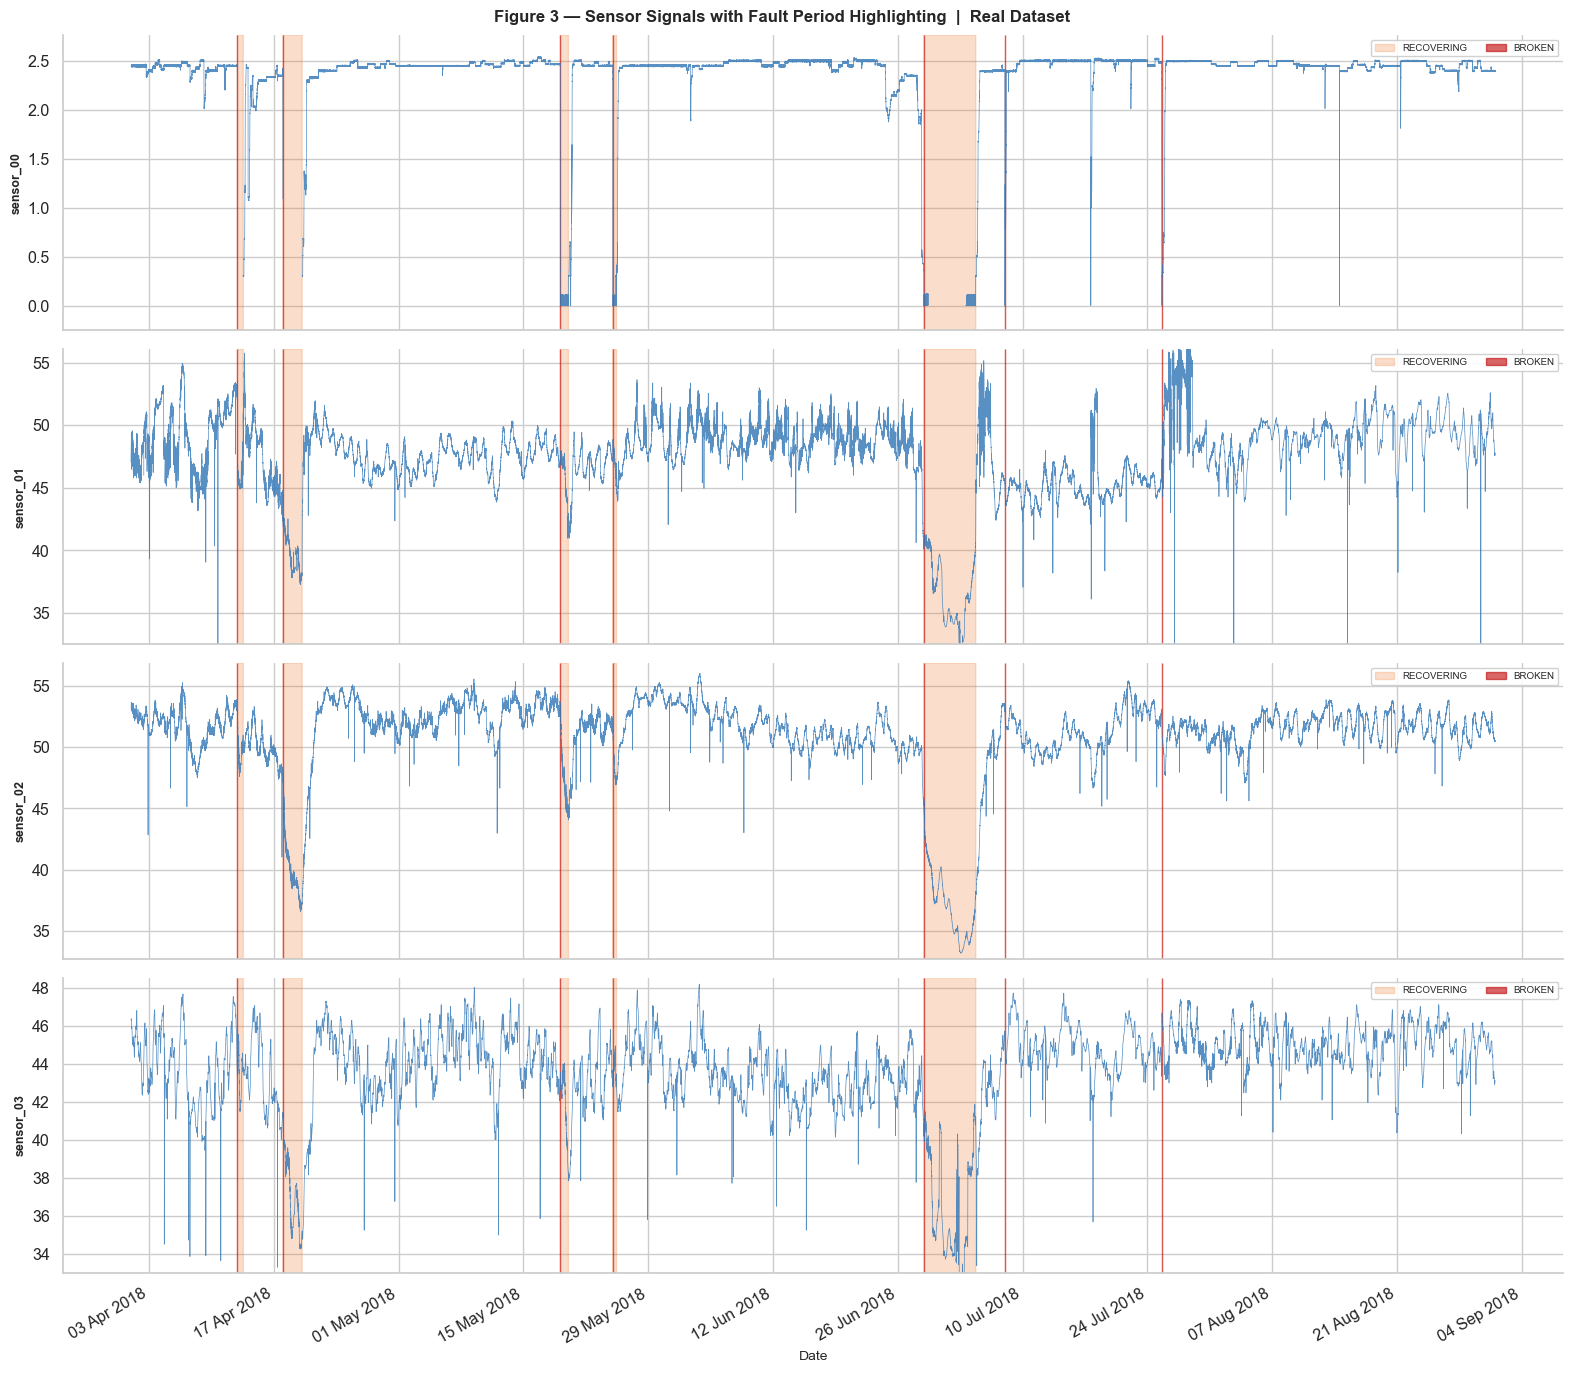

Figure 3 saved → outputs/figures/03_timeseries_faults.png
Sensors plotted: ['sensor_00', 'sensor_01', 'sensor_02', 'sensor_03']


In [ ]:
# Select 4 sensors with <10% missing for clean visualisation
gs = [s for s in sensor_cols if mp.get(s,0) < 10 and s not in to_drop][:4]
bm = df['machine_status'] == 'BROKEN'
rm = df['machine_status'] == 'RECOVERING'

fig, axes = plt.subplots(len(gs), 1, figsize=(16, 3.5*len(gs)), sharex=True)
for ax, s in zip(axes, gs):
    lo = df[s].quantile(0.01); hi = df[s].quantile(0.99)
    pad = (hi - lo) * 0.10
    ax.plot(df.index, df[s], lw=0.5, color='#2E75B6', alpha=0.8)
    ax.fill_between(df.index, lo-pad, hi+pad, where=rm, alpha=0.25, color='#ED7D31', label='RECOVERING')
    ax.fill_between(df.index, lo-pad, hi+pad, where=bm, alpha=0.60, color='#C00000', label='BROKEN')
    ax.set_ylabel(s, fontsize=9, fontweight='bold')
    ax.set_ylim(lo-pad, hi+pad)
    ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.9)

axes[-1].set_xlabel('Date', fontsize=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
axes[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30, ha='right')
fig.suptitle('Figure 3 — Sensor Signals with Fault Period Highlighting  |  Real Dataset',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/03_timeseries_faults.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved → outputs/figures/03_timeseries_faults.png')
print(f'Sensors plotted: {gs}')

## Cell 7 — Figure 4: Sensor Distributions by Class

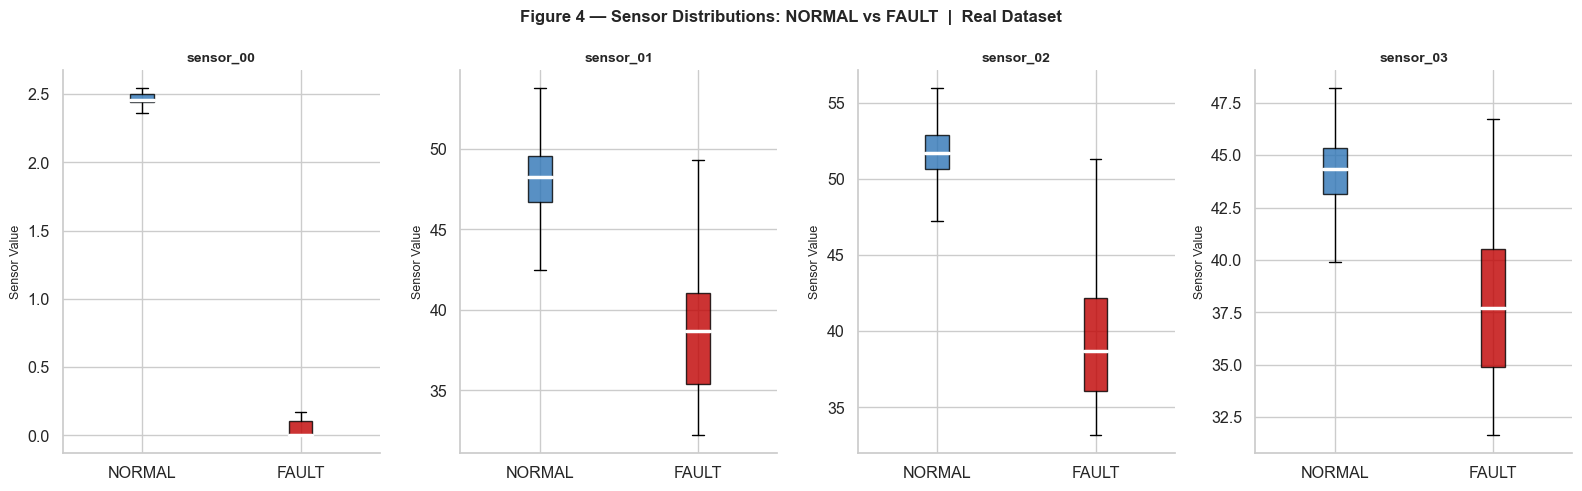

Figure 4 saved → outputs/figures/04_boxplots_class.png


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
for ax, s in zip(axes, gs):
    data = [df[df['fault_label']==x][s].dropna().values for x in ['NORMAL','FAULT']]
    bp = ax.boxplot(data, labels=['NORMAL','FAULT'], patch_artist=True,
                    notch=False, showfliers=False, medianprops=dict(color='white', linewidth=2.5))
    bp['boxes'][0].set_facecolor('#2E75B6'); bp['boxes'][0].set_alpha(0.80)
    bp['boxes'][1].set_facecolor('#C00000'); bp['boxes'][1].set_alpha(0.80)
    ax.set_title(s, fontweight='bold', fontsize=10)
    ax.set_ylabel('Sensor Value', fontsize=9)
fig.suptitle('Figure 4 — Sensor Distributions: NORMAL vs FAULT  |  Real Dataset',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/figures/04_boxplots_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved → outputs/figures/04_boxplots_class.png')

## Cell 8 — Figure 5: Correlation Heatmap
**31 sensor pairs** with |r| > 0.90 confirms strong inter-sensor redundancy, the data are almost identical.  
This justifies applying PCA in Notebook 03 to reduce dimensionality before modelling.

Highly correlated pairs (|r|>0.90): 19


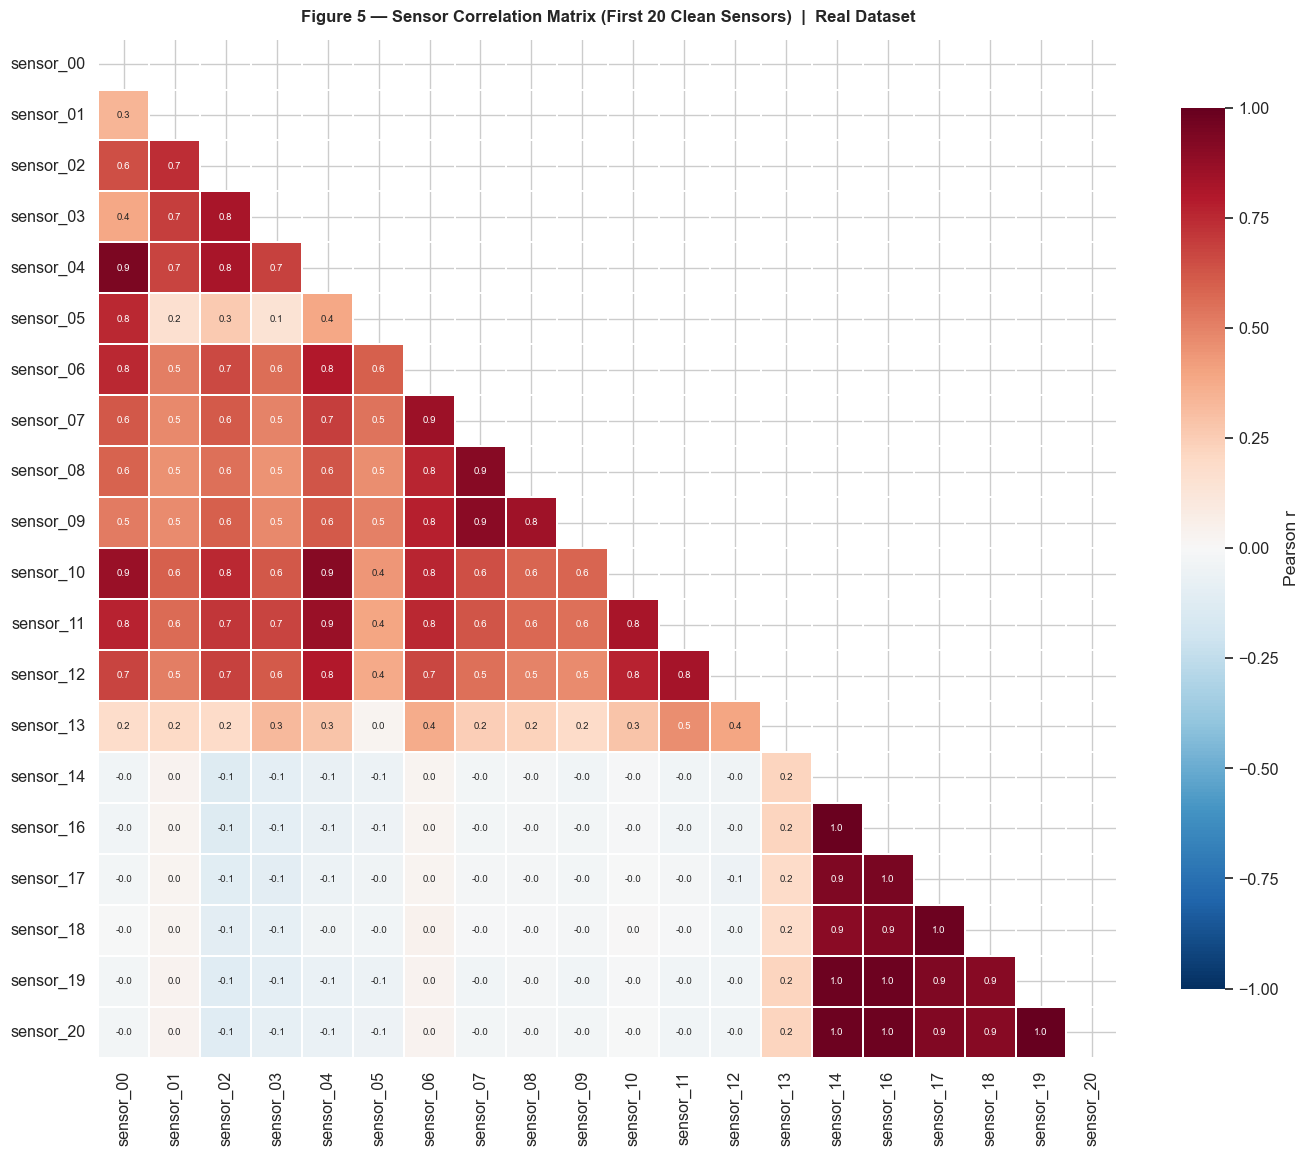

Figure 5 saved → outputs/figures/05_correlation_heatmap.png


In [ ]:
good_s = [s for s in sensor_cols if s not in to_drop and mp.get(s,0) < 20][:20]
cm = df[good_s].corr()
hp = [(cm.columns[i], cm.columns[j], round(cm.iloc[i,j],3))
      for i in range(len(cm.columns))
      for j in range(i+1, len(cm.columns)) if abs(cm.iloc[i,j]) > 0.90]
print(f'Highly correlated pairs (|r|>0.90): {len(hp)}')

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, ax=ax, annot=True, fmt='.1f',
            annot_kws={'size':7}, cbar_kws={'shrink':0.80,'label':'Pearson r'})
ax.set_title('Figure 5 — Sensor Correlation Matrix (First 20 Clean Sensors)  |  Real Dataset',
             fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('outputs/figures/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 saved → outputs/figures/05_correlation_heatmap.png')

## Cell 9 — EDA Summary & Save for Next Notebooks

In [ ]:
print('='*65)
print('EDA SUMMARY OF WORK DONE ')
print('='*65)
print(f'  Dataset rows          : {len(df):,}')
print(f'  Sensor channels       : {len(sensor_cols)} total, drop {len(to_drop)}: {to_drop}')
print(f'  Monitoring period     : {duration} days at 12-minute intervals')
print(f'  Date range            : {df.index.min().date()} to {df.index.max().date()}')
print()
print('  3-class distribution:')
for s in cc3.index:
    print(f'    {s:<12}: {cc3[s]:,} ({cp3[s]:.1f}%)')
print()
print('  Binary (modelling target):')
for s in cc2.index:
    print(f'    {s:<8}: {cc2[s]:,} ({cp2[s]:.1f}%)')
print(f'  Imbalance ratio : {cc2["NORMAL"]/cc2["FAULT"]:.2f}:1 — no SMOTE required')
print(f'  High-corr pairs : {len(hp)} — PCA warranted')
print('='*65)

# Save summary JSON for Notebook 02 to read
summary = {
    'n_rows': len(df), 'n_sensors': len(sensor_cols),
    'duration_days': int(duration), 'sampling_min': 12,
    'time_start': str(df.index.min().date()), 'time_end': str(df.index.max().date()),
    'class_counts_3':    cc3.to_dict(),
    'class_pct_3':       cp3.round(2).to_dict(),
    'class_counts_binary': cc2.to_dict(),
    'class_pct_binary':    cp2.round(2).to_dict(),
    'sensors_to_drop':   to_drop,
    'good_sensors':      gs,
    'high_corr_pairs':   len(hp),
    'target_col':        'fault_label',
    'label_map':         {'NORMAL': 0, 'FAULT': 1}
}
with open('outputs/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nSummary saved → outputs/eda_summary.json')
print('NEXT: Run Notebook 02 — Preprocessing')

EDA SUMMARY OF WORK DONE 
  Dataset rows          : 220,320
  Sensor channels       : 52 total, drop 2: ['sensor_15', 'sensor_50']
  Monitoring period     : 152 days at 12-minute intervals
  Date range            : 2018-04-01 to 2018-08-31

  3-class distribution:
    NORMAL      : 205,836 (93.4%)
    RECOVERING  : 14,477 (6.6%)
    BROKEN      : 7 (0.0%)

  Binary (modelling target):
    NORMAL  : 205,836 (93.4%)
    FAULT   : 14,484 (6.6%)
  Imbalance ratio : 14.21:1 — no SMOTE required
  High-corr pairs : 19 — PCA warranted

Summary saved → outputs/eda_summary.json
NEXT: Run Notebook 02 — Preprocessing
